# Decision Tree From Scratch: Job Applicant Shortlisting

In this notebook I implement a **decision tree classifier from scratch** (no scikit-learn for the core algorithm) and use it to predict whether a job applicant should be **shortlisted for an interview**, based on three simple yes/no attributes about the applicant.

This is my own practice project for learning how decision trees work internally: entropy, information gain, and recursive splitting. The structure of the exercise is inspired by the Decision Tree lab in DeepLearning.AI's *Machine Learning Specialization* (Course 2, Week 4), but the **dataset, story, code, and explanations here are my own** — rewritten from scratch with a completely different problem (job shortlisting instead of mushroom edibility) so I could actually understand each step instead of just filling in blanks.

## Outline
- [1 - Import Packages](#1)
- [2 - Problem Statement](#2)
- [3 - Dataset](#3)
- [4 - Decision Tree Building Blocks](#4)
    - [4.1 Entropy](#4.1)
    - [4.2 Splitting the Dataset](#4.2)
    - [4.3 Information Gain](#4.3)
    - [4.4 Choosing the Best Split](#4.4)
- [5 - Building the Full Tree](#5)
- [6 - Visualizing the Tree](#6)
- [7 - Using the Tree to Make Predictions](#7)
- [8 - Bonus: Comparing With scikit-learn](#8)
- [9 - Conclusion](#9)


<a name="1"></a>
## 1 - Import Packages

Everything below runs with just `numpy` and `matplotlib` for the from-scratch part, and `scikit-learn` for the bonus comparison at the end. No external helper files are needed — the whole notebook is self-contained, so it will run top to bottom on its own (e.g. after cloning from GitHub).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.set_printoptions(precision=4, suppress=True)

<a name="2"></a>
## 2 - Problem Statement

Imagine you're helping out with hiring at a small tech company. Every applicant who applies gets looked at on three simple attributes:

1. **Relevant Degree** — does the applicant have a CS/IT-related degree?
2. **Prior Experience** — does the applicant have relevant work or internship experience?
3. **Employee Referral** — was the applicant referred by a current employee?

Based on historical data of past applicants, we want to learn a simple decision tree that predicts whether an applicant gets **shortlisted** for an interview.

> Note: this dataset is invented for learning purposes and does not reflect a real or fair hiring process — in real life you should never build a hiring decision purely off referrals, since it can encode bias. It's used here only because it's a clean, intuitive example of a splittable binary dataset.

<a name="3"></a>
## 3 - Dataset

Here are 10 past applicants:

| Applicant | Relevant Degree | Prior Experience | Employee Referral | Shortlisted |
|:---------:|:----------------:|:-----------------:|:-------------------:|:-----------:|
| 0 | Yes | Yes | Yes | **Yes** |
| 1 | Yes | Yes | No  | **Yes** |
| 2 | Yes | No  | No  | No |
| 3 | No  | Yes | No  | No |
| 4 | No  | No  | Yes | **Yes** |
| 5 | Yes | No  | Yes | **Yes** |
| 6 | No  | Yes | Yes | No |
| 7 | No  | No  | No  | No |
| 8 | Yes | Yes | Yes | **Yes** |
| 9 | Yes | No  | No  | No |

Each column is one-hot encoded as `1` (Yes) or `0` (No):
- `X_train` has 3 columns: `[Relevant Degree, Prior Experience, Employee Referral]`
- `y_train` is `1` if the applicant was shortlisted, `0` otherwise

Applicant 6 is deliberately a bit "noisy" — referred but not shortlisted (maybe they didn't clear the interview screen) — so the data isn't perfectly clean, just like real life.

In [2]:
X_train = np.array([
    [1, 1, 1],   # 0
    [1, 1, 0],   # 1
    [1, 0, 0],   # 2
    [0, 1, 0],   # 3
    [0, 0, 1],   # 4
    [1, 0, 1],   # 5
    [0, 1, 1],   # 6
    [0, 0, 0],   # 7
    [1, 1, 1],   # 8
    [1, 0, 0],   # 9
])

y_train = np.array([1, 1, 0, 0, 1, 1, 0, 0, 1, 0])

feature_names = ["Relevant Degree", "Prior Experience", "Employee Referral"]
class_names = ["Not Shortlisted", "Shortlisted"]

#### View and check the data

Always a good habit: look at the raw arrays and confirm their shapes before doing anything else.

In [3]:
print("First 5 rows of X_train:\n", X_train[:5])
print("Type of X_train:", type(X_train))
print()
print("First 5 values of y_train:", y_train[:5])
print("Type of y_train:", type(y_train))

First 5 rows of X_train:
 [[1 1 1]
 [1 1 0]
 [1 0 0]
 [0 1 0]
 [0 0 1]]
Type of X_train: <class 'numpy.ndarray'>

First 5 values of y_train: [1 1 0 0 1]
Type of y_train: <class 'numpy.ndarray'>


In [4]:
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Number of training examples (m):", len(X_train))
print("Number shortlisted:", int(np.sum(y_train)), "/", len(y_train))

Shape of X_train: (10, 3)
Shape of y_train: (10,)
Number of training examples (m): 10
Number shortlisted: 5 / 10


<a name="4"></a>
## 4 - Decision Tree Building Blocks

A decision tree is built greedily and recursively:

1. Start with all examples at the root node.
2. For every feature, compute how much **information** would be gained by splitting on it.
3. Split on the feature with the **highest information gain**.
4. Repeat on each resulting branch until a stopping condition is met (e.g. max depth, or a pure node).

To do this we need four building blocks: **entropy**, **splitting**, **information gain**, and **best-split selection**.

<a name="4.1"></a>
### 4.1 Entropy

Entropy measures how "mixed" the labels are at a node. If a node is 100% one class, entropy is `0` (totally pure). If it's a 50/50 mix, entropy is `1` (maximally impure, for a binary label).

$$H(p_1) = -p_1 \log_2(p_1) - (1 - p_1)\log_2(1 - p_1)$$

where $p_1$ is the fraction of examples in the node that are labeled `1`. By convention $0 \log_2(0) = 0$.

In [5]:
def compute_entropy(y):
    """
    Computes entropy for a set of labels.

    Args:
        y (ndarray): Array of 0/1 labels for the examples at a node.

    Returns:
        entropy (float): Entropy at that node.
    """
    entropy = 0.

    if len(y) != 0:
        p1 = len(y[y == 1]) / len(y)
        if p1 != 0 and p1 != 1:
            entropy = -p1 * np.log2(p1) - (1 - p1) * np.log2(1 - p1)
        else:
            entropy = 0.

    return entropy

In [6]:
# Sanity checks
root_entropy = compute_entropy(y_train)
print("Entropy at the root node (5 shortlisted, 5 not):", root_entropy)

assert np.isclose(root_entropy, 1.0), "Expected entropy of 1.0 for a perfectly balanced node"
assert compute_entropy(np.array([1, 1, 1, 1])) == 0.0, "A pure node should have 0 entropy"
assert compute_entropy(np.array([])) == 0.0, "An empty node should have 0 entropy"
print("compute_entropy passed all sanity checks!")

Entropy at the root node (5 shortlisted, 5 not): 1.0
compute_entropy passed all sanity checks!


<a name="4.2"></a>
### 4.2 Splitting the Dataset

Given a node (a list of example indices) and a feature to split on, we divide the examples into:
- **Left branch**: examples where that feature is `1`
- **Right branch**: examples where that feature is `0`

In [7]:
def split_dataset(X, node_indices, feature):
    """
    Splits the data at a node into left (feature == 1) and right (feature == 0) branches.

    Args:
        X (ndarray):          Data matrix of shape (n_samples, n_features).
        node_indices (list):  Indices of the examples currently at this node.
        feature (int):        Index of the feature to split on.

    Returns:
        left_indices (list), right_indices (list)
    """
    left_indices = []
    right_indices = []

    for i in node_indices:
        if X[i][feature] == 1:
            left_indices.append(i)
        else:
            right_indices.append(i)

    return left_indices, right_indices

In [8]:
root_indices = list(range(len(X_train)))

# Try splitting the root node on each feature and see how the applicants divide up
for f, name in enumerate(feature_names):
    left, right = split_dataset(X_train, root_indices, f)
    print(f"Split on '{name}' -> Left (Yes): {left} | Right (No): {right}")

# Sanity check using the feature we already know: Employee Referral (feature 2)
left, right = split_dataset(X_train, root_indices, 2)
assert left == [0, 4, 5, 6, 8]
assert right == [1, 2, 3, 7, 9]
print("\nsplit_dataset passed the sanity check!")

Split on 'Relevant Degree' -> Left (Yes): [0, 1, 2, 5, 8, 9] | Right (No): [3, 4, 6, 7]
Split on 'Prior Experience' -> Left (Yes): [0, 1, 3, 6, 8] | Right (No): [2, 4, 5, 7, 9]
Split on 'Employee Referral' -> Left (Yes): [0, 4, 5, 6, 8] | Right (No): [1, 2, 3, 7, 9]

split_dataset passed the sanity check!


<a name="4.3"></a>
### 4.3 Information Gain

Information gain tells us how much splitting on a feature reduces entropy (impurity):

$$\text{Information Gain} = H(p_1^{\text{node}}) - \left( w^{\text{left}} H(p_1^{\text{left}}) + w^{\text{right}} H(p_1^{\text{right}}) \right)$$

where $w^{\text{left}}$ and $w^{\text{right}}$ are the fraction of examples that went to the left/right branch.

In [9]:
def compute_information_gain(X, y, node_indices, feature):
    """
    Computes the information gain from splitting the node on the given feature.

    Args:
        X (ndarray):            Data matrix of shape (n_samples, n_features).
        y (ndarray):             Labels for all examples.
        node_indices (list):     Indices of the examples currently at this node.
        feature (int):           Index of the feature to split on.

    Returns:
        information_gain (float)
    """
    left_indices, right_indices = split_dataset(X, node_indices, feature)

    y_node = y[node_indices]
    y_left = y[left_indices]
    y_right = y[right_indices]

    node_entropy = compute_entropy(y_node)
    left_entropy = compute_entropy(y_left)
    right_entropy = compute_entropy(y_right)

    w_left = len(y_left) / len(y_node)
    w_right = len(y_right) / len(y_node)

    weighted_entropy = w_left * left_entropy + w_right * right_entropy
    information_gain = node_entropy - weighted_entropy

    return information_gain

In [10]:
for f, name in enumerate(feature_names):
    ig = compute_information_gain(X_train, y_train, root_indices, f)
    print(f"Information gain from splitting on '{name}': {ig:.4f}")

# Sanity checks against hand-verified values for this dataset
assert np.isclose(compute_information_gain(X_train, y_train, root_indices, 0), 0.1245, atol=1e-3)
assert np.isclose(compute_information_gain(X_train, y_train, root_indices, 1), 0.0290, atol=1e-3)
assert np.isclose(compute_information_gain(X_train, y_train, root_indices, 2), 0.2781, atol=1e-3)
print("\ncompute_information_gain passed all sanity checks!")

Information gain from splitting on 'Relevant Degree': 0.1245
Information gain from splitting on 'Prior Experience': 0.0290
Information gain from splitting on 'Employee Referral': 0.2781

compute_information_gain passed all sanity checks!


**Observation:** Splitting on **Employee Referral** gives the highest information gain at the root. That matches intuition from the table above — referred applicants were shortlisted 4 out of 5 times, while non-referred applicants were shortlisted only 1 out of 5 times, so this feature separates the two classes the most cleanly.

<a name="4.4"></a>
### 4.4 Choosing the Best Split

Now we just try every feature and keep whichever one gives the highest information gain.

In [11]:
def get_best_split(X, y, node_indices):
    """
    Finds the feature that gives the highest information gain when splitting this node.

    Args:
        X (ndarray):            Data matrix of shape (n_samples, n_features).
        y (ndarray):             Labels for all examples.
        node_indices (list):     Indices of the examples currently at this node.

    Returns:
        best_feature (int): Index of the best feature to split on (-1 if no split helps).
    """
    num_features = X.shape[1]
    best_feature = -1
    max_info_gain = 0

    for feature in range(num_features):
        info_gain = compute_information_gain(X, y, node_indices, feature)
        if info_gain > max_info_gain:
            max_info_gain = info_gain
            best_feature = feature

    return best_feature

In [12]:
best_feature = get_best_split(X_train, y_train, root_indices)
print(f"Best feature to split the root node on: {best_feature} ('{feature_names[best_feature]}')")

assert best_feature == 2
print("get_best_split passed the sanity check!")

Best feature to split the root node on: 2 ('Employee Referral')
get_best_split passed the sanity check!


<a name="5"></a>
## 5 - Building the Full Tree

We now repeat the process recursively: at every node, find the best feature, split, and recurse into the left and right branches, stopping once we hit a maximum depth (here, `max_depth=2`) or once a node is already pure (all one class).

In [13]:
tree_splits = []  # keeps a record of (left_indices, right_indices, feature) for each split made


def build_tree_recursive(X, y, node_indices, branch_name, max_depth, current_depth):
    """
    Recursively builds a decision tree, printing its structure as it goes.

    Args:
        X, y:                    Training data and labels.
        node_indices (list):     Indices of examples at the current node.
        branch_name (str):       'Root', 'Left', or 'Right' -- just for display.
        max_depth (int):         Maximum depth allowed.
        current_depth (int):     Current recursion depth.
    """
    labels = y[node_indices]

    # Stop if we've hit max depth OR the node is already pure (all same label)
    if current_depth == max_depth or len(set(labels)) == 1:
        indent = "  " * current_depth + "-" * current_depth
        print(f"{indent} {branch_name} leaf node with indices {node_indices}")
        return

    best_feature = get_best_split(X, y, node_indices)
    indent = "-" * current_depth
    print(f"{indent} Depth {current_depth}, {branch_name}: split on feature {best_feature} "
          f"('{feature_names[best_feature]}')")

    left_indices, right_indices = split_dataset(X, node_indices, best_feature)
    tree_splits.append((left_indices, right_indices, best_feature))

    build_tree_recursive(X, y, left_indices, "Left", max_depth, current_depth + 1)
    build_tree_recursive(X, y, right_indices, "Right", max_depth, current_depth + 1)


build_tree_recursive(X_train, y_train, root_indices, "Root", max_depth=2, current_depth=0)

 Depth 0, Root: split on feature 2 ('Employee Referral')
- Depth 1, Left: split on feature 0 ('Relevant Degree')
    -- Left leaf node with indices [0, 5, 8]
    -- Right leaf node with indices [4, 6]
- Depth 1, Right: split on feature 1 ('Prior Experience')
    -- Left leaf node with indices [1, 3]
    -- Right leaf node with indices [2, 7, 9]


<a name="6"></a>
## 6 - Visualizing the Tree

Rather than just reading indices off the printout above, let's draw the tree. To make this reusable (and to actually classify new applicants later), I'll build the tree as a small nested dictionary instead of just a flat list of splits.

In [14]:
def build_tree(X, y, node_indices, max_depth, depth=0):
    """
    Recursively builds a decision tree and returns it as a nested dict:
      - Leaf node:     {"leaf": True, "prediction": 0/1, "n": count, "pos": positive_count}
      - Internal node: {"leaf": False, "feature": f, "left": <subtree>, "right": <subtree>}
    """
    labels = y[node_indices]

    if len(set(labels)) == 1 or depth == max_depth:
        values, counts = np.unique(labels, return_counts=True)
        prediction = int(values[np.argmax(counts)])
        return {"leaf": True, "prediction": prediction,
                "n": len(node_indices), "pos": int(labels.sum())}

    best_feature = get_best_split(X, y, node_indices)
    if best_feature == -1:
        values, counts = np.unique(labels, return_counts=True)
        prediction = int(values[np.argmax(counts)])
        return {"leaf": True, "prediction": prediction,
                "n": len(node_indices), "pos": int(labels.sum())}

    left_indices, right_indices = split_dataset(X, node_indices, best_feature)
    return {
        "leaf": False,
        "feature": best_feature,
        "left": build_tree(X, y, left_indices, max_depth, depth + 1),
        "right": build_tree(X, y, right_indices, max_depth, depth + 1),
    }


def assign_positions(node, depth, counter):
    """Walks the tree and assigns (x, y) plotting coordinates to every node, in place."""
    if node["leaf"]:
        node["x"] = counter[0]
        counter[0] += 1
    else:
        assign_positions(node["left"], depth + 1, counter)
        assign_positions(node["right"], depth + 1, counter)
        node["x"] = (node["left"]["x"] + node["right"]["x"]) / 2
    node["y"] = -depth


def _collect_y(node):
    if node["leaf"]:
        return [node["y"]]
    return _collect_y(node["left"]) + _collect_y(node["right"]) + [node["y"]]


def plot_tree(tree, feature_names, class_names, title):
    """Draws the decision tree using matplotlib boxes and connecting lines."""
    counter = [0]
    assign_positions(tree, 0, counter)
    n_leaves = counter[0]
    depth = -min(_collect_y(tree))

    fig, ax = plt.subplots(figsize=(2.6 * n_leaves, 1.8 * (depth + 1)))
    box_w, box_h = 0.85, 0.7

    def draw(node):
        x, y = node["x"], node["y"]
        if node["leaf"]:
            label = f"LEAF\n{class_names[node['prediction']]}\n({node['pos']}/{node['n']})"
            color = "#c8e6c9" if node["prediction"] == 1 else "#ffcdd2"
        else:
            label = f"{feature_names[node['feature']]}?"
            color = "#bbdefb"

        rect = plt.Rectangle((x - box_w / 2, y - box_h / 2), box_w, box_h,
                              facecolor=color, edgecolor="black", zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, label, ha="center", va="center", fontsize=9, zorder=4)

        if not node["leaf"]:
            for child, tag in [(node["left"], "Yes"), (node["right"], "No")]:
                cx, cy = child["x"], child["y"]
                ax.plot([x, cx], [y - box_h / 2, cy + box_h / 2], color="gray", zorder=1)
                mx, my = (x + cx) / 2, (y + cy) / 2
                ax.text(mx, my, tag, fontsize=8.5, color="dimgray", ha="center", va="center",
                        bbox=dict(boxstyle="round", fc="white", ec="none", alpha=0.85), zorder=5)
            draw(node["left"])
            draw(node["right"])

    draw(tree)
    ax.set_xlim(-0.6, n_leaves - 0.4)
    ax.set_ylim(-(depth + 0.7), 0.7)
    ax.axis("off")
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

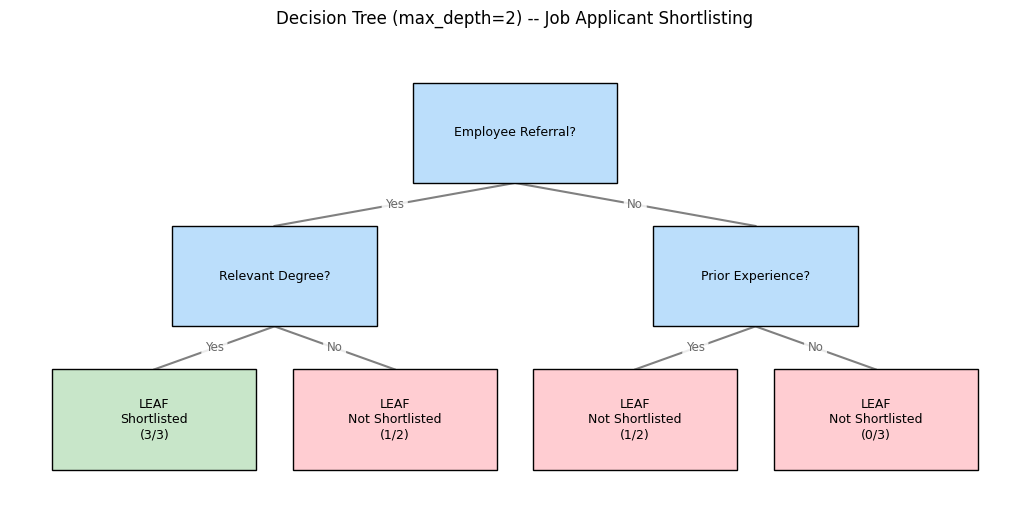

In [15]:
tree_depth2 = build_tree(X_train, y_train, root_indices, max_depth=2)
plot_tree(tree_depth2, feature_names, class_names,
          "Decision Tree (max_depth=2) -- Job Applicant Shortlisting")

Two of the four leaves aren't fully pure (`1/2` and `1/2`) — a `max_depth=2` tree can't perfectly separate every applicant in this dataset. Let's see what happens if we let it grow one level deeper.

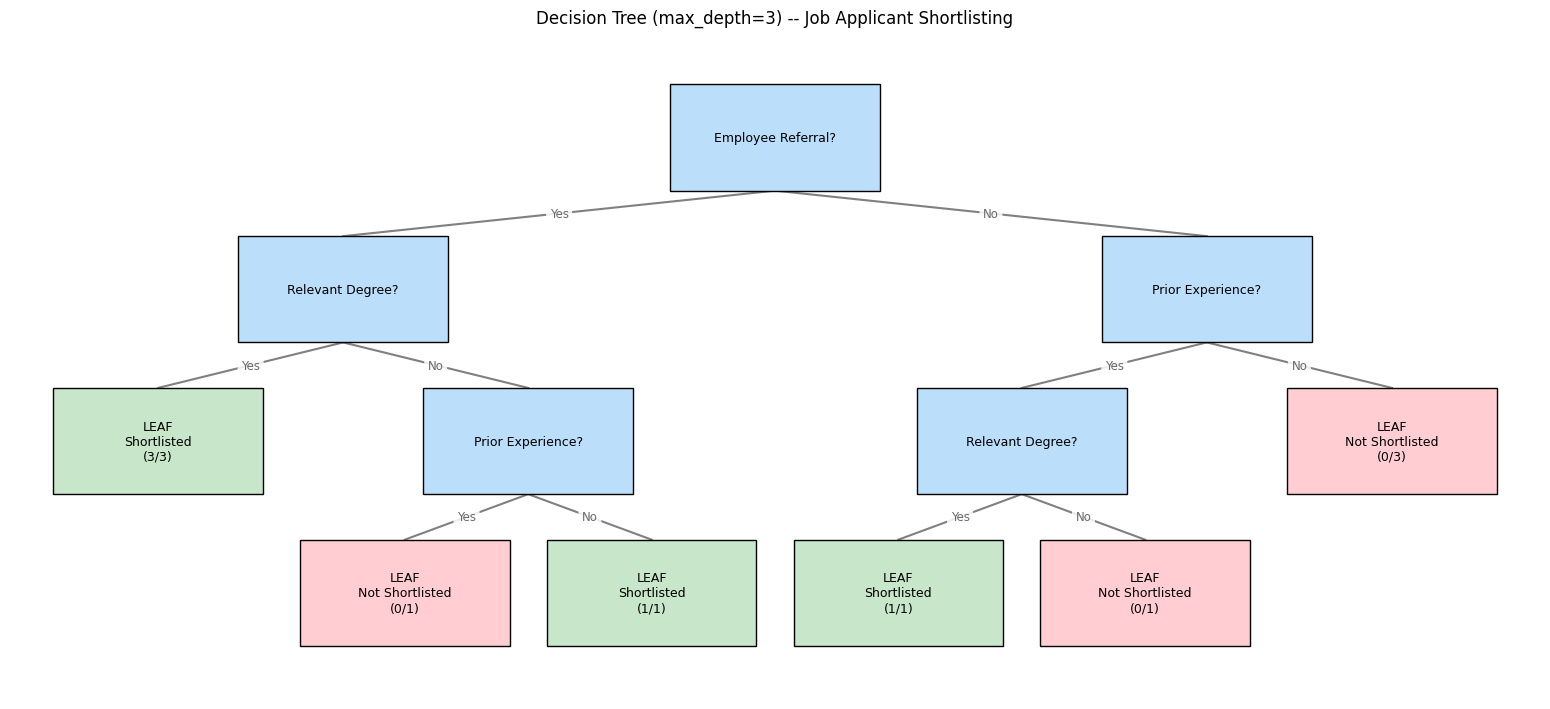

In [16]:
tree_depth3 = build_tree(X_train, y_train, root_indices, max_depth=3)
plot_tree(tree_depth3, feature_names, class_names,
          "Decision Tree (max_depth=3) -- Job Applicant Shortlisting")

With `max_depth=3` every leaf is now pure (a clean `n/n` or `0/n`). With only 3 binary features, depth 3 is enough to distinguish every unique combination of attributes in this dataset — this is a nice illustration of how tree depth trades off between underfitting (too shallow, leaves stay mixed) and just memorizing the training set (too deep, on a bigger dataset this would start to overfit).

<a name="7"></a>
## 7 - Using the Tree to Make Predictions

Now that the tree is a nested dictionary, we can walk it to classify brand-new applicants who weren't in the training data.

In [17]:
def predict(tree, x):
    """
    Classifies a single example x = [Relevant Degree, Prior Experience, Employee Referral]
    by walking the tree.
    """
    if tree["leaf"]:
        return tree["prediction"]
    if x[tree["feature"]] == 1:
        return predict(tree["left"], x)
    else:
        return predict(tree["right"], x)


new_applicants = np.array([
    [0, 0, 0],   # no degree, no experience, no referral
    [1, 0, 0],   # degree only
    [0, 1, 1],   # experience + referral, no degree
    [1, 1, 0],   # degree + experience, no referral
])

print("Predictions using the depth-2 tree:")
for applicant in new_applicants:
    pred = predict(tree_depth2, applicant)
    values = [int(v) for v in applicant]
    print(f"  {dict(zip(feature_names, values))} -> {class_names[pred]}")

Predictions using the depth-2 tree:
  {'Relevant Degree': 0, 'Prior Experience': 0, 'Employee Referral': 0} -> Not Shortlisted
  {'Relevant Degree': 1, 'Prior Experience': 0, 'Employee Referral': 0} -> Not Shortlisted
  {'Relevant Degree': 0, 'Prior Experience': 1, 'Employee Referral': 1} -> Not Shortlisted
  {'Relevant Degree': 1, 'Prior Experience': 1, 'Employee Referral': 0} -> Not Shortlisted


**A gotcha worth noticing:** the last row, `[Degree=1, Experience=1, Referral=0]`, is predicted **"Not Shortlisted"** — but that's the *exact same feature combination* as training applicant #1, who actually **was** shortlisted! This isn't a bug — it's the depth-2 tree being honest about its limits. That applicant lands in a leaf (`indices [1, 3]`) that mixes one shortlisted and one non-shortlisted example, and our majority-vote code just breaks the tie by defaulting to class `0`.

This is exactly the impure leaf we spotted back in Section 6. Let's confirm the deeper tree (`max_depth=3`), which we showed makes every leaf pure, fixes this.

In [18]:
print("Predictions using the depth-3 tree (fully pure leaves):")
for applicant in new_applicants:
    pred = predict(tree_depth3, applicant)
    values = [int(v) for v in applicant]
    print(f"  {dict(zip(feature_names, values))} -> {class_names[pred]}")

Predictions using the depth-3 tree (fully pure leaves):
  {'Relevant Degree': 0, 'Prior Experience': 0, 'Employee Referral': 0} -> Not Shortlisted
  {'Relevant Degree': 1, 'Prior Experience': 0, 'Employee Referral': 0} -> Not Shortlisted
  {'Relevant Degree': 0, 'Prior Experience': 1, 'Employee Referral': 1} -> Not Shortlisted
  {'Relevant Degree': 1, 'Prior Experience': 1, 'Employee Referral': 0} -> Shortlisted


<a name="8"></a>
## 8 - Bonus: Comparing With scikit-learn

As a sanity check (and to see the "industry standard" way of doing this), let's fit scikit-learn's `DecisionTreeClassifier` on the same data and compare.

Training accuracy: 0.8
Feature importances: {'Relevant Degree': np.float64(0.2682734124061352), 'Prior Experience': np.float64(0.2682734124061352), 'Employee Referral': np.float64(0.4634531751877295)}


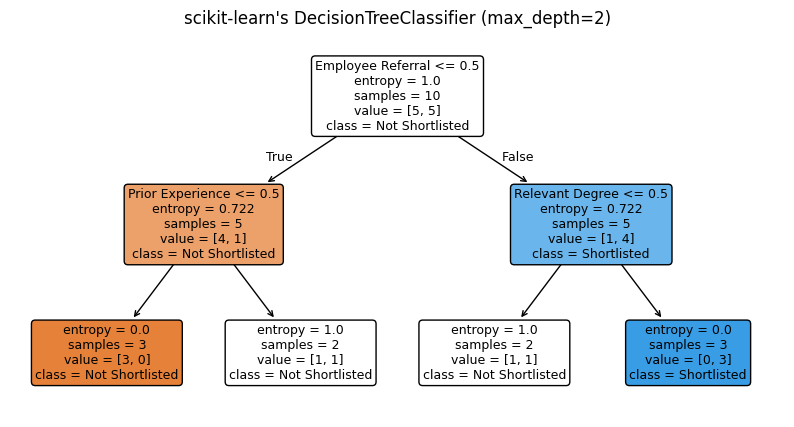

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree as sk_plot_tree

clf = DecisionTreeClassifier(criterion="entropy", max_depth=2, random_state=0)
clf.fit(X_train, y_train)

print("Training accuracy:", clf.score(X_train, y_train))
print("Feature importances:", dict(zip(feature_names, clf.feature_importances_)))

plt.figure(figsize=(10, 5))
sk_plot_tree(clf, feature_names=feature_names, class_names=class_names,
             filled=True, rounded=True, fontsize=9)
plt.title("scikit-learn's DecisionTreeClassifier (max_depth=2)")
plt.show()

scikit-learn picks the same root split (**Employee Referral**) that our from-scratch implementation found — a good confirmation that the entropy/information-gain logic above is correct.

<a name="9"></a>
## 9 - Conclusion

In this notebook I implemented, from scratch:
- **Entropy** — measuring impurity of a node's labels
- **Dataset splitting** — dividing examples by a feature's value
- **Information gain** — measuring how much a split reduces impurity
- **Best-split selection** — picking the most informative feature
- A **recursive tree builder** that combines all of the above, plus a simple **prediction function** to classify new examples
- A custom **tree visualization**, and a comparison against **scikit-learn**

### Ideas to explore further
- Try changing `max_depth` and see how the tree (and its accuracy) changes.
- Add a 4th feature (e.g. "Portfolio/GitHub provided") and see if it changes the best split.
- Swap in a real-world dataset (e.g. the UCI Mushroom dataset, or a small Kaggle CSV) and reuse every function above unchanged — that's the benefit of writing the core logic generically.
- Extend `compute_entropy` to a Gini-impurity version and compare the resulting trees.

---
*Adapted as an original learning exercise from the Decision Tree assignment structure in DeepLearning.AI's Machine Learning Specialization (Course 2, Week 4) — dataset, code, and explanations rewritten from scratch by me for practice.*